# Task 1: MLP - California Housing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

torch.manual_seed(42)
np.random.seed(42)

## 1. Load Dataset

In [2]:
df = pd.read_csv("california_housing.csv")
features = df.drop(columns = ['MedHouseVal']).columns.tolist()
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. EDA

In [3]:
print(df.describe())
print('\nMissing values:', df.isnull().sum().sum())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

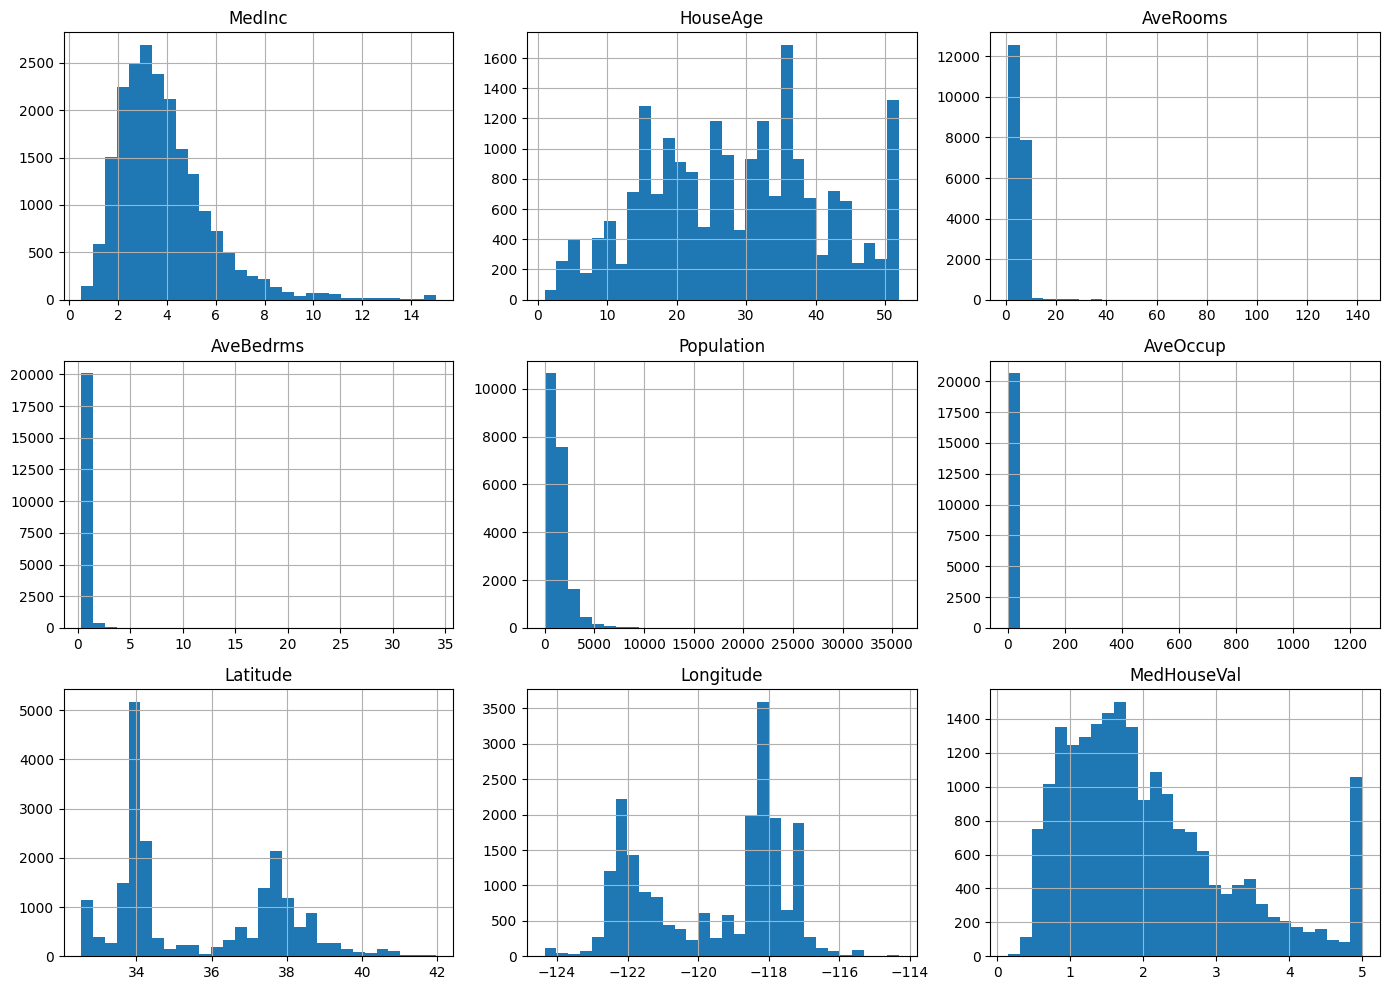

In [4]:
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

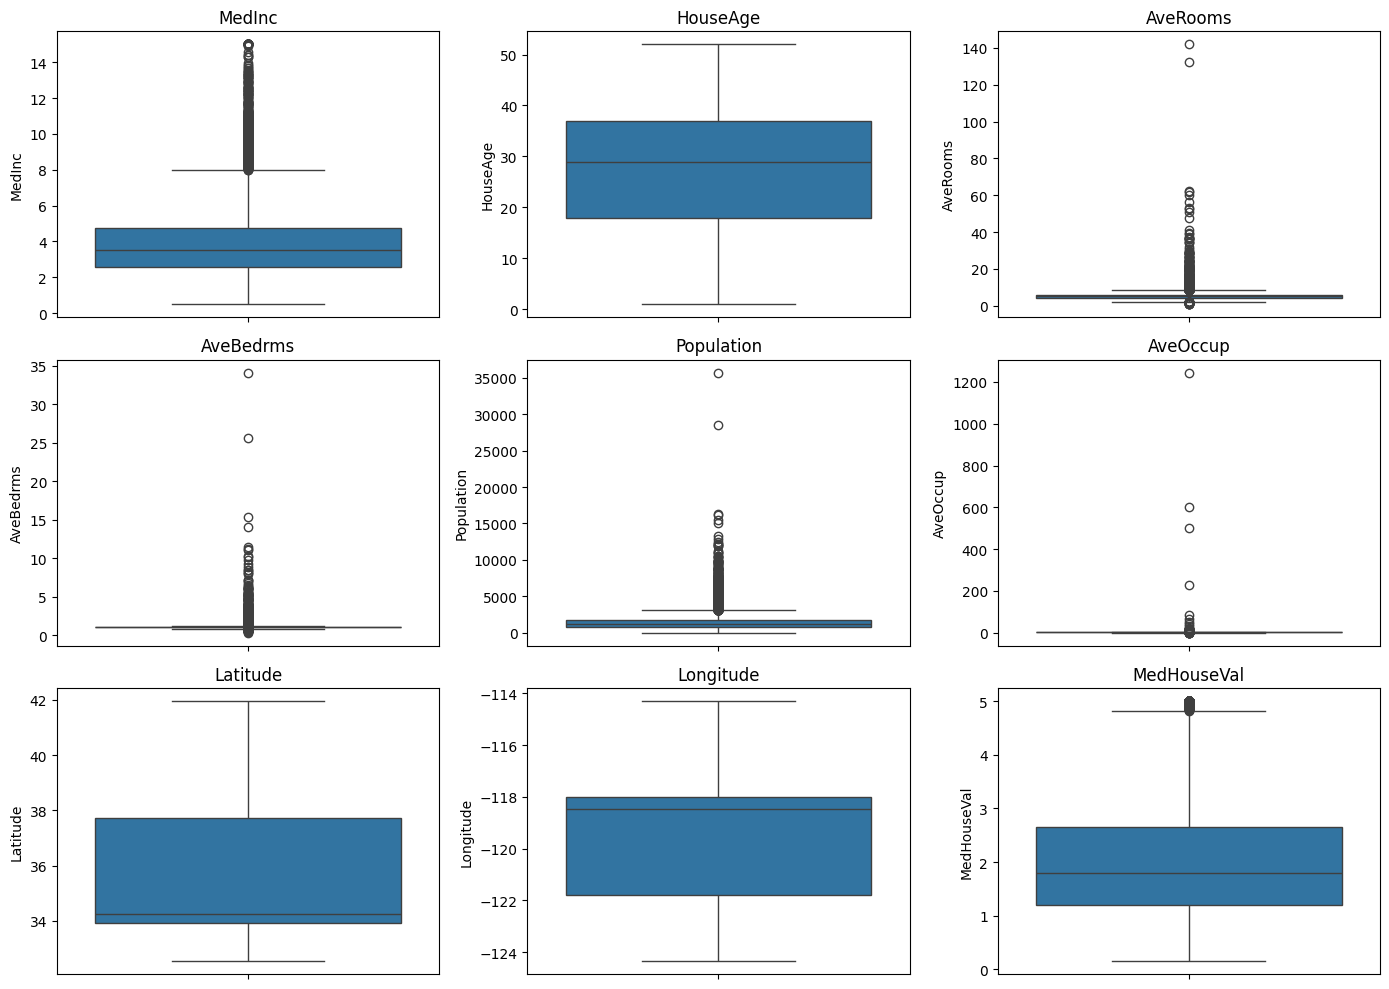

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for ax, col in zip(axes.flatten(), df.columns):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

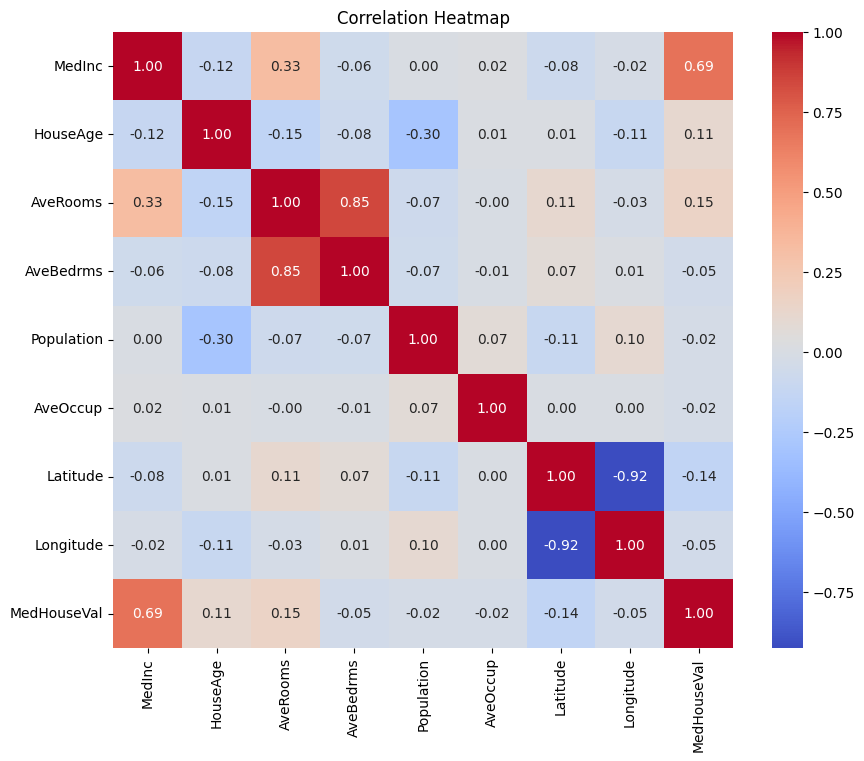

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

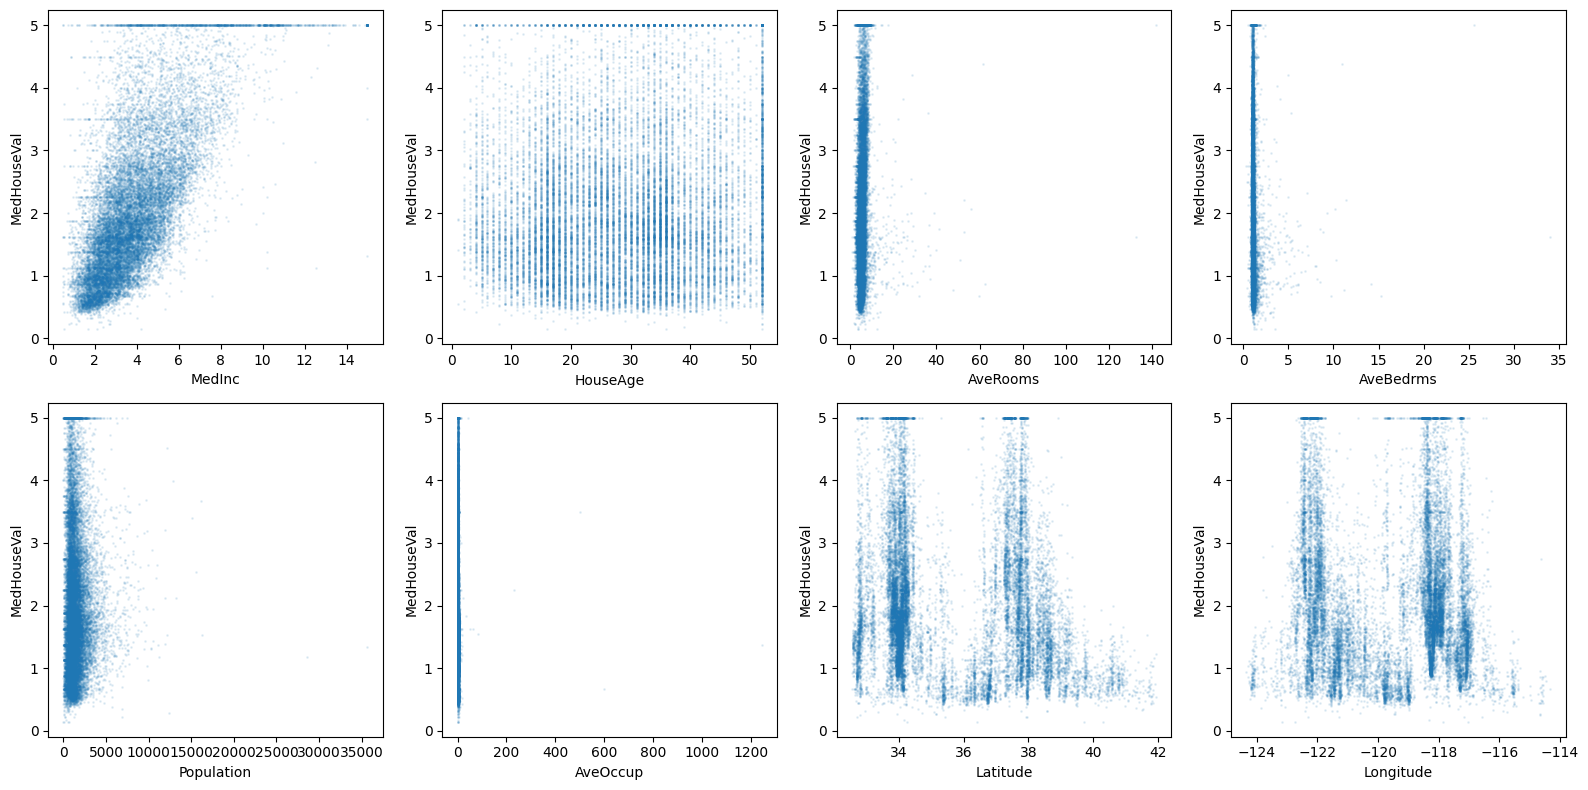

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(df.columns):
    if(col == 'MedHouseVal'):
        continue;
    ax = axes[i//4][i%4]
    ax.scatter(df[col], df['MedHouseVal'], alpha=0.1, s=1)
    ax.set_xlabel(col)
    ax.set_ylabel('MedHouseVal')
plt.tight_layout()
plt.show()

## 3. Data Preparation

In [8]:
X = df.drop('MedHouseVal', axis=1).values
y = df['MedHouseVal'].values

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def to_tensors(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).unsqueeze(1)

X_train_t, y_train_t = to_tensors(X_train, y_train)
X_val_t, y_val_t = to_tensors(X_val, y_val)
X_test_t, y_test_t = to_tensors(X_test, y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (14448, 8) Val: (3096, 8) Test: (3096, 8)


## 4 & 5. Baseline MLP + Training

In [9]:
class MLP(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

In [10]:
def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3, patience=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val_loss = float('inf')
    best_weights = None
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss += criterion(model(xb), yb).item()
        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pt")
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"Epoch {epoch+1}: New best model (val={val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}')

    model.load_state_dict(torch.load("best_model.pt"))
    return train_losses, val_losses

Epoch 1: New best model (val=0.5268)
Epoch 2: New best model (val=0.4232)
Epoch 3: New best model (val=0.3969)
Epoch 4: New best model (val=0.3749)
Epoch 5: New best model (val=0.3685)
Epoch 6: New best model (val=0.3506)
Epoch 7: New best model (val=0.3456)
Epoch 8: New best model (val=0.3381)
Epoch 9: New best model (val=0.3375)
Epoch 10: train=0.3120, val=0.3377
Epoch 11: New best model (val=0.3235)
Epoch 13: New best model (val=0.3149)
Epoch 17: New best model (val=0.3086)
Epoch 19: New best model (val=0.3017)
Epoch 20: New best model (val=0.2995)
Epoch 20: train=0.2789, val=0.2995
Epoch 23: New best model (val=0.2942)
Epoch 30: train=0.2702, val=0.3018
Early stopping at epoch 33


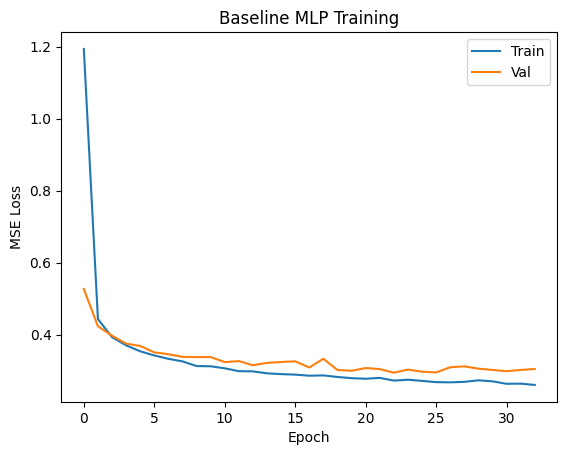

In [11]:
baseline_model = MLP(X_train.shape[1])
train_losses, val_losses = train_model(baseline_model, train_loader, val_loader)

plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Baseline MLP Training')
plt.legend()
plt.show()

## 6. Feature Engineering

In [12]:
def add_features(df):
    df = df.copy()
    eps = 1e-5
    df['RoomsPerPerson'] = df['AveRooms'] / (df['AveOccup'] + eps)
    df['BedroomRatio'] = df['AveBedrms'] / (df['AveRooms'] + eps)
    df['PopDensity'] = df['Population'] / (df['AveOccup'] + eps)
    df['IncomePerRoom'] = df['MedInc'] / (df['AveRooms'] + eps)
    df['LogPopulation'] = np.log1p(df['Population'])
    return df

new_features = features + ['RoomsPerPerson', 'BedroomRatio', 'PopDensity', 'IncomePerRoom', 'LogPopulation']
df_eng = add_features(df.drop('MedHouseVal', axis=1))
X_eng = df_eng.values

X_train_e, X_tmp_e, y_train_e, y_tmp_e = train_test_split(X_eng, y, test_size=0.3, random_state=42)
X_val_e, X_test_e, y_val_e, y_test_e = train_test_split(X_tmp_e, y_tmp_e, test_size=0.5, random_state=42)

scaler_e = StandardScaler()
X_train_e = scaler_e.fit_transform(X_train_e)
X_val_e = scaler_e.transform(X_val_e)
X_test_e = scaler_e.transform(X_test_e)

X_train_et, y_train_et = to_tensors(X_train_e, y_train_e)
X_val_et, y_val_et = to_tensors(X_val_e, y_val_e)
X_test_et, y_test_et = to_tensors(X_test_e, y_test_e)

train_loader_e = DataLoader(TensorDataset(X_train_et, y_train_et), batch_size=64, shuffle=True)
val_loader_e = DataLoader(TensorDataset(X_val_et, y_val_et), batch_size=64)

print('New feature count:', X_eng.shape[1])

New feature count: 13


## 7. Enhanced MLP

Epoch 1: New best model (val=0.4286)
Epoch 2: New best model (val=0.3743)
Epoch 3: New best model (val=0.3601)
Epoch 5: New best model (val=0.3374)
Epoch 6: New best model (val=0.3264)
Epoch 7: New best model (val=0.3186)
Epoch 9: New best model (val=0.3116)
Epoch 10: train=0.2914, val=0.3213
Epoch 13: New best model (val=0.3012)
Epoch 15: New best model (val=0.3002)
Epoch 16: New best model (val=0.3001)
Epoch 17: New best model (val=0.2974)
Epoch 20: train=0.2617, val=0.3037
Epoch 22: New best model (val=0.2922)
Epoch 30: train=0.2437, val=0.2994
Epoch 31: New best model (val=0.2862)
Epoch 38: New best model (val=0.2854)
Epoch 40: train=0.2248, val=0.3050
Epoch 43: New best model (val=0.2853)
Epoch 50: train=0.2162, val=0.2886
Early stopping at epoch 53


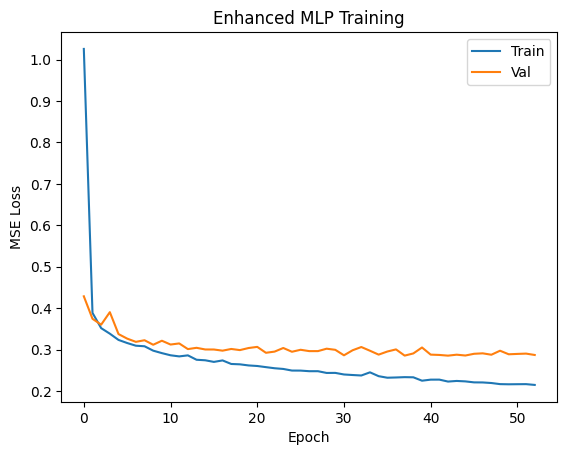

In [13]:
enhanced_model = MLP(X_train_e.shape[1])
train_losses_e, val_losses_e = train_model(enhanced_model, train_loader_e, val_loader_e)

plt.plot(train_losses_e, label='Train')
plt.plot(val_losses_e, label='Val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Enhanced MLP Training')
plt.legend()
plt.show()

## 8. Evaluation & Comparison

In [14]:
def evaluate(model, X_t, y_t):
    model.eval()
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    y = y_t.squeeze().numpy()
    mae = mean_absolute_error(y, preds)
    rmse = mean_squared_error(y, preds) ** 0.5
    r2 = r2_score(y, preds)
    return preds, mae, rmse, r2

preds_b, mae_b, rmse_b, r2_b = evaluate(baseline_model, X_test_t, y_test_t)
preds_e, mae_e, rmse_e, r2_e = evaluate(enhanced_model, X_test_et, y_test_et)

results = pd.DataFrame({
    'Model': ['Baseline', 'Enhanced'],
    'MAE': [mae_b, mae_e],
    'RMSE': [rmse_b, rmse_e],
    'R2': [r2_b, r2_e]
})
print(results)

      Model       MAE      RMSE        R2
0  Baseline  0.356023  0.512116  0.801664
1  Enhanced  0.344344  0.502406  0.809113


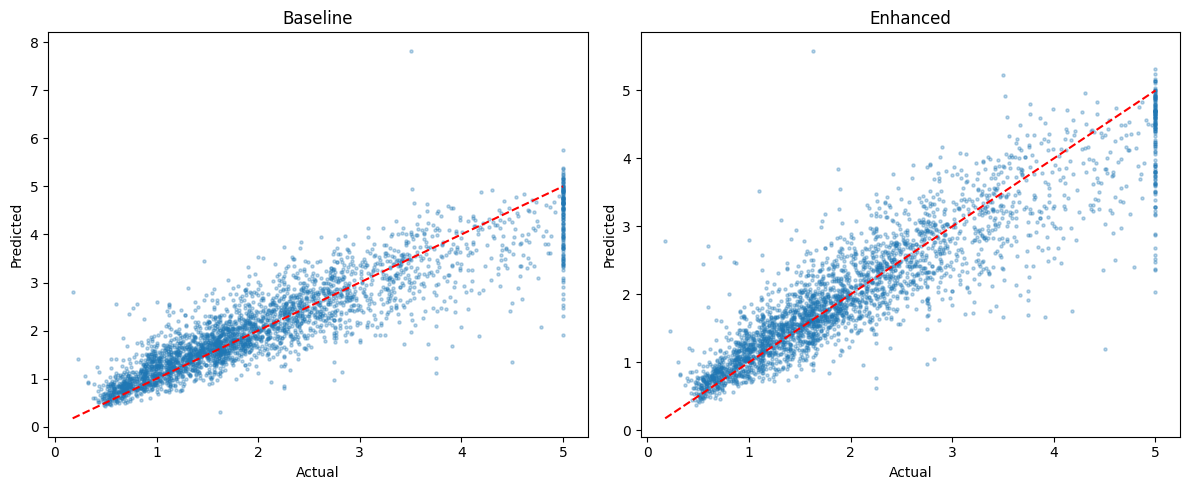

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
y_true = y_test_t.squeeze().numpy()
y_true_e = y_test_et.squeeze().numpy()

for ax, preds, y_true_p, title in zip(axes,
    [preds_b, preds_e], [y_true, y_true_e], ['Baseline', 'Enhanced']):
    ax.scatter(y_true_p, preds, alpha=0.3, s=5)
    ax.plot([y_true_p.min(), y_true_p.max()], [y_true_p.min(), y_true_p.max()], 'r--')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 9. Error Analysis

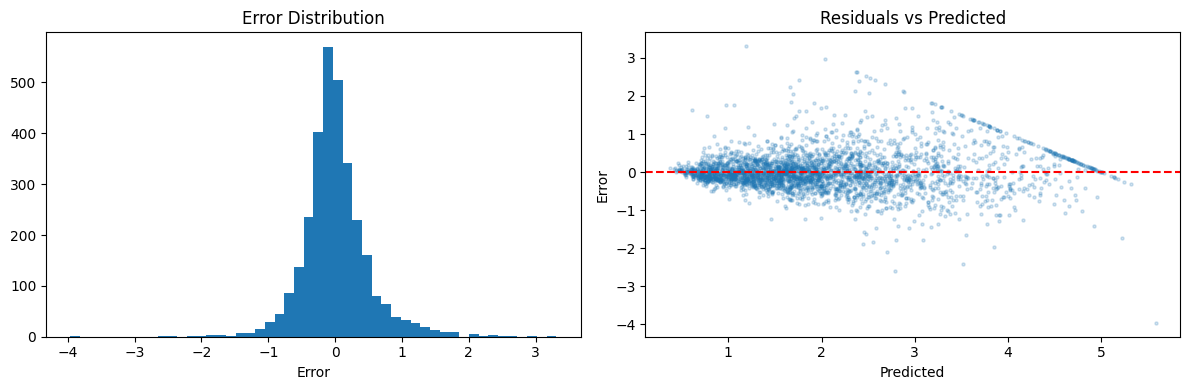

Top 10 worst predictions:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerPerson,BedroomRatio,PopDensity,IncomePerRoom,LogPopulation,Actual,Predicted,AbsError
9,0.392740,0.430075,51.801923,73.675806,-1.220790,-0.058129,1.474635,-0.247595,45.992196,0.753859,-1.271744,-2.640859,-4.638740,1.62500,5.584774,3.959774
8,-1.107174,0.826486,-0.178572,-0.467380,-1.233069,-0.054537,0.926797,-0.666995,0.054040,-0.604509,-1.287442,-1.405379,-5.284166,4.50000,1.191361,3.308639
7,-0.811874,-0.204181,-1.472765,0.092278,-0.701576,-0.138040,0.997033,-1.415923,-0.595996,7.048969,-0.146706,2.175040,-0.792426,5.00001,2.035100,2.964910
6,-0.078322,0.350793,-0.274012,-0.077483,-0.380576,-0.030788,-0.758858,0.586213,-0.209452,0.172546,-0.361245,0.256192,-0.169825,5.00001,2.364365,2.635645
5,1.635888,-1.234847,0.403690,-0.219077,-1.147118,-0.021182,-1.002342,1.200334,0.230743,-0.985331,-1.201102,1.441067,-3.030181,5.00001,2.378109,2.621902
4,-0.792817,0.826486,-0.760413,0.266733,-1.025208,-0.100413,-0.702670,0.626155,-0.068615,2.188705,-0.949930,-0.207814,-1.991780,0.17500,2.784709,2.609710
3,-0.603405,-0.917719,0.055497,-0.104148,-0.655093,-0.094844,-0.594975,0.017027,0.761941,-0.418684,-0.395259,-0.879214,-0.682600,5.00001,2.480533,2.519477
2,1.027596,-1.076283,0.473042,-0.332948,-0.905929,-0.048760,-1.264555,1.160391,0.552782,-1.186403,-0.900218,0.651572,-1.420602,5.00001,2.518991,2.481019
1,-0.432525,1.698588,-0.129662,0.933047,-0.797175,-0.065672,-0.997659,0.890777,0.204526,1.421590,-0.722305,-0.464438,-1.050777,5.00001,2.574181,2.425829
0,1.136949,-0.759155,-0.243987,0.553420,-1.000650,0.034265,1.085998,-1.375981,-0.533050,1.114053,-1.099063,2.064453,-1.852928,1.10000,3.522482,2.422482


In [16]:
# Enhanced is better
errors = y_true_e - preds_e

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(errors, bins=50)
plt.xlabel('Error')
plt.title('Error Distribution')

plt.subplot(1, 2, 2)
plt.scatter(preds_e, errors, alpha=0.2, s=5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Error')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.show()

abs_errors = np.abs(errors)
hard_idx = np.argsort(abs_errors)[-10:]

worst_cases = pd.DataFrame(X_test_e[hard_idx], columns = new_features)

worst_cases['Actual'] = y_true_e[hard_idx]
worst_cases['Predicted'] = preds_e[hard_idx]
worst_cases['AbsError'] = abs_errors[hard_idx]

worst_cases = worst_cases.sort_values(
    'AbsError',
    ascending=False
)

print('Top 10 worst predictions:')
display(worst_cases)

## 10. Conclusion

**Summary**

In this project, two Multi-Layer Perceptron (MLP) models were developed to predict median house values using the California Housing dataset. The first model served as a baseline and was trained using the original eight features. The second model incorporated five additional engineered features, including rooms per person, bedroom ratio, population density, income per room, and a logarithmic transformation of the population.

The preprocessing pipeline included a 70/15/15 train-validation-test split, feature normalization using StandardScaler (fitted only on the training set to prevent data leakage), and early stopping to reduce overfitting. Both models were trained under the same conditions to ensure a fair comparison.

**Can feature engineering improve deep learning models on structured tabular datasets?**

Based on the experimental results, the answer is **yes**. The enhanced model consistently outperformed the baseline model across all evaluation metrics. Specifically, the Mean Absolute Error (MAE) decreased from 0.3560 to 0.3443, the Root Mean Squared Error (RMSE) decreased from 0.5121 to 0.5024, and the R² score increased from 0.8017 to 0.8091.

Although MLPs are capable of learning complex non-linear relationships, manually engineered features can provide more informative representations of the data by incorporating domain knowledge. These additional features help the model capture meaningful relationships more efficiently, resulting in improved prediction accuracy and better generalization on unseen data.

**Future Work**

Several improvements could further enhance model performance:

- Incorporating Batch Normalization to improve training stability and convergence.
- Applying Dropout as an additional regularization technique to reduce overfitting.
- Using learning rate scheduling to achieve more efficient optimization.
- Performing systematic hyperparameter optimization with tools such as Optuna.
- Comparing the MLP with ensemble methods or gradient boosting algorithms (e.g., XGBoost, LightGBM, or CatBoost), which often achieve superior performance on structured tabular datasets.

Overall, this project demonstrates that while deep learning models are powerful, feature engineering remains an important technique for improving performance on structured tabular data, especially when domain-specific knowledge can be incorporated into the input features.

### Question 1

An MLP is equivalent to Logistic Regression if:

1. It has no hidden layers.
2. The input is connected directly to the output layer.
3. The output layer uses the appropriate activation function:
    - Sigmoid for binary classification.
    - Softmax for multiclass classification.
4. No additional non-linear transformations are applied before the output.

Why? Because for binary classification, Logistic Regression predicts the probability of the positive class by applying the sigmoid function to a linear combination of the input features:

$\hat{y}=\sigma(\mathbf{w}^T\mathbf{x}+b)$

An MLP with no hidden layers performs exactly the same computation:

$\hat{y}=\sigma(Wx+b)$

Since both models consist of a single linear transformation followed by a sigmoid activation, they are mathematically equivalent and can only learn linear decision boundaries.

And for multiclass classification with $K$ classes, Multinomial Logistic Regression computes a score for each class:

$
z_i=\mathbf{w}_i^T\mathbf{x}+b_i,
\qquad i=1,\ldots,K
$

The scores are converted into probabilities using the softmax function:

$
P(y=i\mid x)=
\frac{e^{z_i}}
{\sum_{j=1}^{K}e^{z_j}}
$

An MLP with no hidden layers performs the same operations:

$
z=Wx+b,
$

followed by

$
\hat{y}=\mathrm{softmax}(z).
$

Therefore, an MLP without hidden layers is mathematically equivalent to multinomial logistic regression.

And the equivalence between an MLP and Logistic Regression holds only when the MLP has no hidden layers. Once a hidden layer with a non-linear activation function is added, the network can learn complex non-linear relationships between the input features. Logistic Regression is limited to learning linear decision boundaries, whereas an MLP can build hierarchical feature representations and model much more complicated patterns. As a result, an MLP with hidden layers is no longer mathematically equivalent to Logistic Regression.